     측정년도  측정소명  이산화질소농도(ppm)  오존농도(ppm)  일산화탄소농도(ppm)  아황산가스(ppm)  미세먼지(㎍/㎥)  \
0    2026   강남구        0.0234     0.0266          0.47      0.0025       42.0   
1    2026  강남대로        0.0268     0.0208          0.59      0.0028       48.0   
2    2026   강동구        0.0227     0.0284          0.56      0.0027       48.0   
3    2026  강변북로        0.0299     0.0226          0.52      0.0028       49.0   
4    2026   강북구        0.0165     0.0309          0.44      0.0023       43.0   
..    ...   ...           ...        ...           ...         ...        ...   
685  2012  청계천로        0.0470     0.0160          0.60      0.0060       43.0   
686  2012  한강대로        0.0490     0.0110          0.70      0.0050       49.0   
687  2012   홍릉로        0.0480     0.0120          0.60      0.0060       50.0   
688  2012   홍지문        0.0440     0.0140          0.50      0.0060       39.0   
689  2012   화랑로        0.0440     0.0130          0.70      0.0050       49.0   

     초미세먼지(㎍/㎥)  
0        

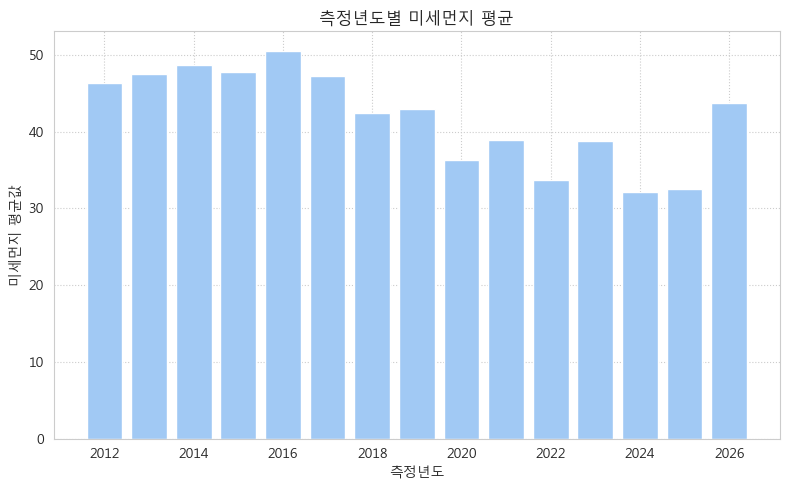

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')   # 배경 스타일 설정
sns.set_palette('pastel')    # 색상 스타일 설정

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv("greenData/seoul.csv",encoding='cp949')

# 결측치 제거
df = df.dropna()
print(df)

# 측청년도별 기준 미세먼지 평균
# df_year = df.groupby('측정년도')['미세먼지(㎍/㎥)'].mean().reset_index()
df_year = df.groupby('측정년도')['미세먼지(㎍/㎥)'].mean()

print(df_year.values)

df1 = pd.DataFrame({
    "측정년도": df_year.index,
    "미세먼지(㎍/㎥)": df_year.values
})

plt.figure(figsize=(8,5))

plt.bar(
    df1["측정년도"],
    df1["미세먼지(㎍/㎥)"]
)

plt.title("측정년도별 미세먼지 평균")
plt.xlabel("측정년도")
plt.ylabel("미세먼지 평균값")

plt.grid(linestyle=':')
plt.tight_layout()

plt.savefig("seoul.png", dpi=300, transparent=True)
plt.show()

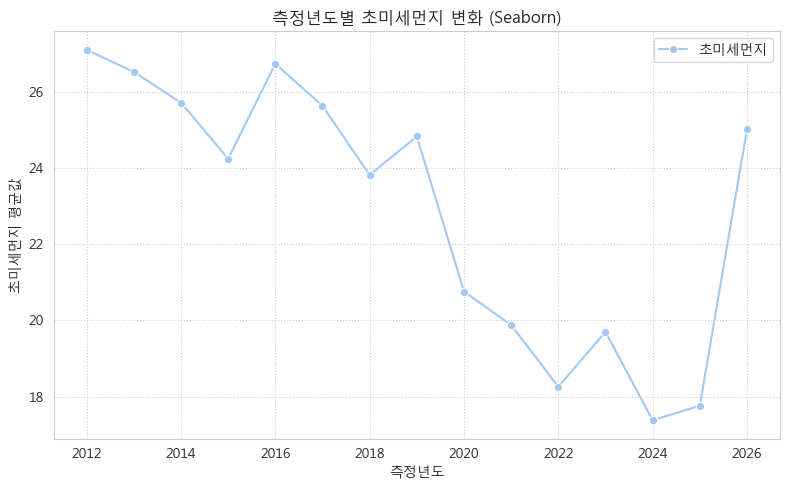

In [23]:
plt.figure(figsize=(8,5))

df_year = df.groupby('측정년도')['초미세먼지(㎍/㎥)'].mean()

df2 = pd.DataFrame({
    "측정년도": df_year.index,
    "초미세먼지(㎍/㎥)": df_year.values
})

sns.lineplot(
    data=df2,
    x="측정년도",
    y="초미세먼지(㎍/㎥)",
    marker='o'
)

plt.title("측정년도별 초미세먼지 변화 (Seaborn)")
plt.xlabel("측정년도")
plt.ylabel("초미세먼지 평균값")

plt.legend(["초미세먼지"])
plt.grid(linestyle=':')
plt.tight_layout()
plt.savefig("seoul02.png", dpi=300, transparent=True)

plt.show()